In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
%matplotlib widget

In [75]:
df = pd.read_csv(r'C:\Users\raithel-lab\Desktop\PlotValues1.csv', skiprows = 1, usecols = [0,1], encoding = 'latin1')
data = df.to_numpy()

dist, sig = data[:,0]*3.45, data[:,1]
# dist_fit, sig_fit = data[:,2], data[:,3]

In [76]:
print(len(dist))

91


In [77]:
def func(x,a,b,c,d):
    return a + (b-a)*np.exp(-(x-c)**2/(2*d*d))

In [81]:
initial_guess = [0.002,2000,150,20]
weight=np.ones_like(dist)
weight[45:55] = 0.00001
print(weight)
sigma = 1/np.sqrt(weight)

print(sigma)
popt1, pcov1 = curve_fit(
            func, dist, sig, p0 = initial_guess, sigma = sigma, maxfev = 10000000, method ='lm')

[1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00
 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00
 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00
 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00
 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e-05 1.e-05 1.e-05 1.e-05 1.e-05
 1.e-05 1.e-05 1.e-05 1.e-05 1.e-05 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00
 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00
 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00
 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00
 1.e+00]
[  1.           1.           1.           1.           1.
   1.           1.           1.           1.           1.
   1.           1.           1.           1.           1.
   1.           1.           1.           1.           1.
   1.           1.           1.           1.           1.
   1.           1.           1.           1.           1.
   1

In [82]:
popt1

array([ 17.14676403, 207.47732392, 147.54971826,  11.78901999])

In [86]:
popt1[1] = 300

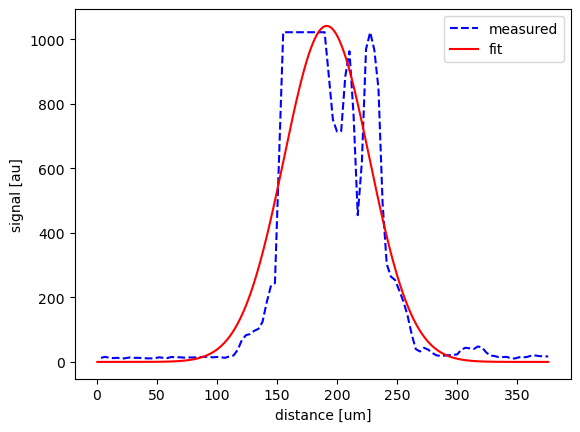

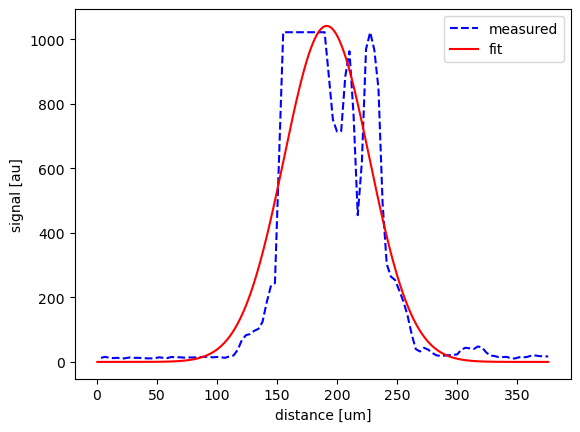

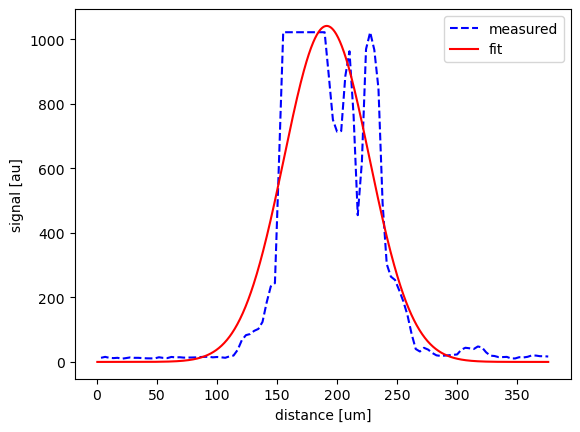

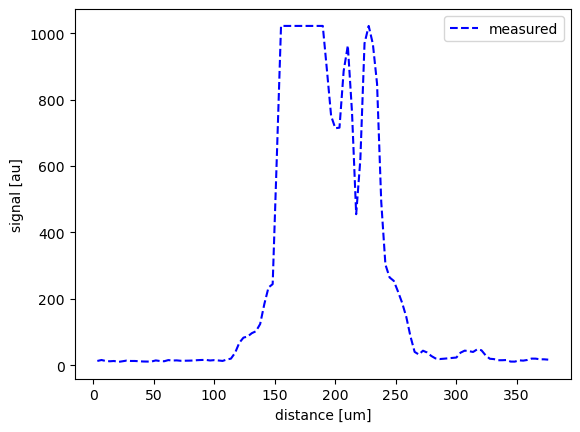

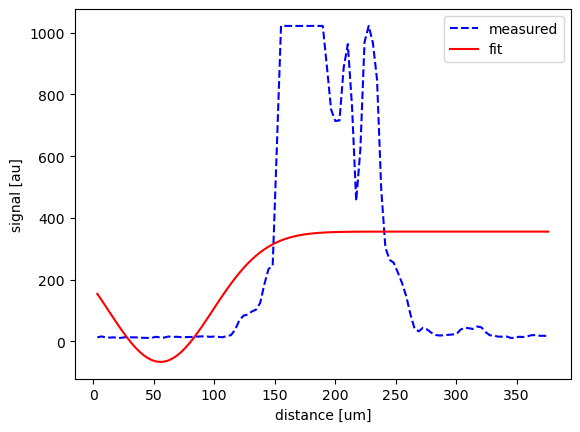

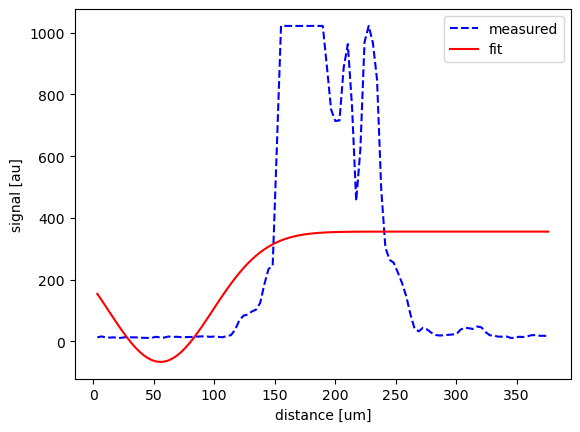

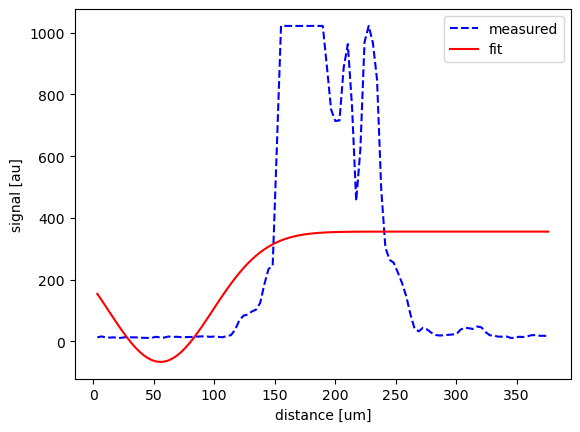

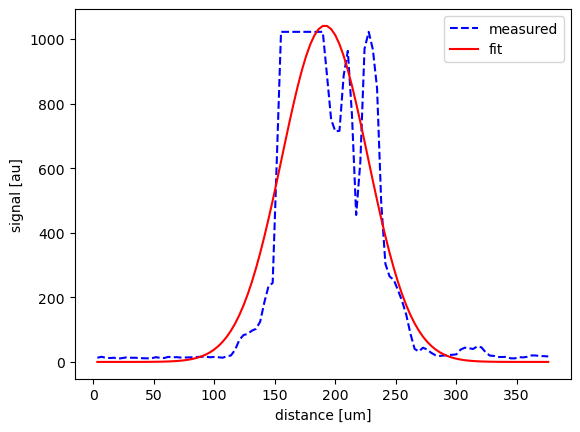

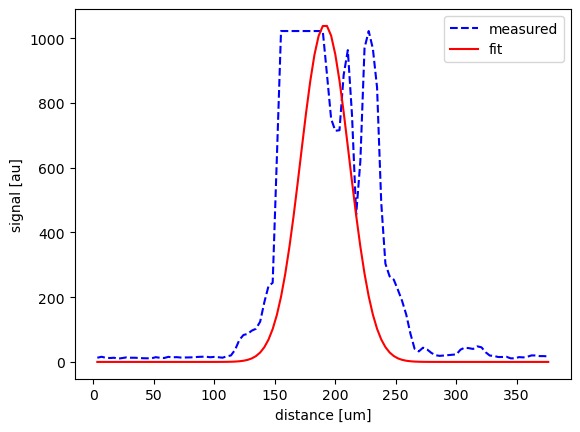

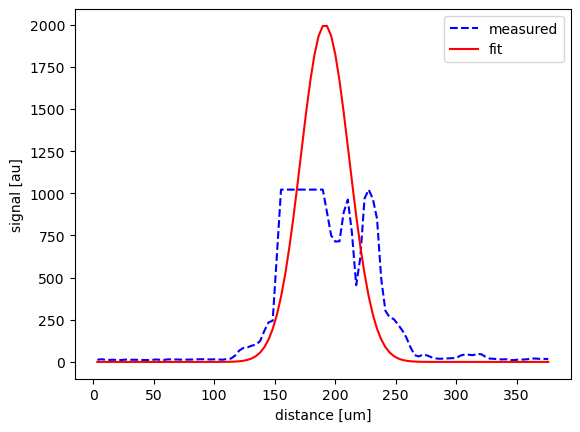

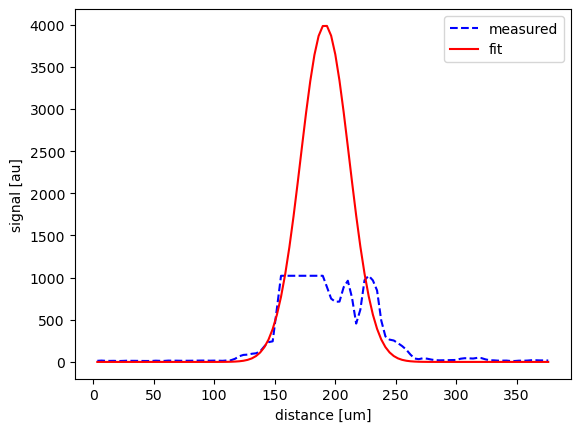

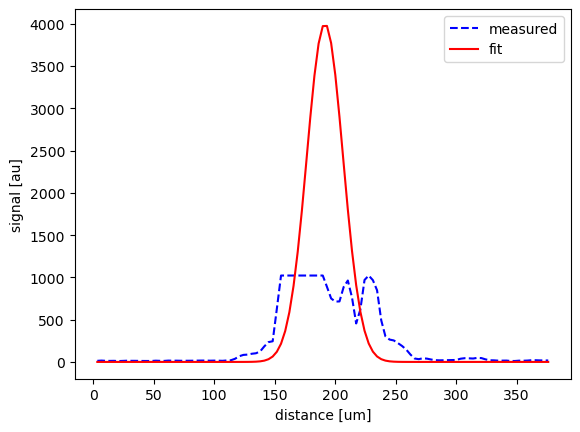

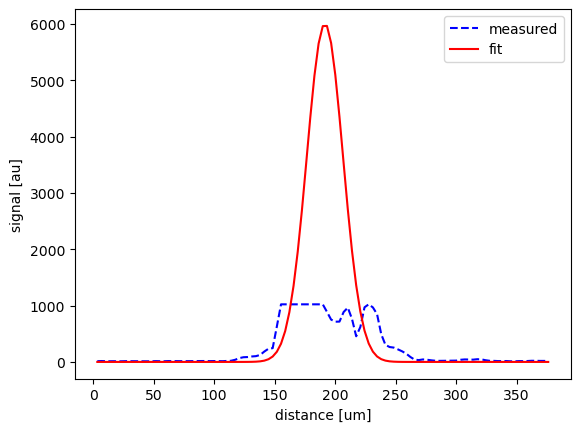

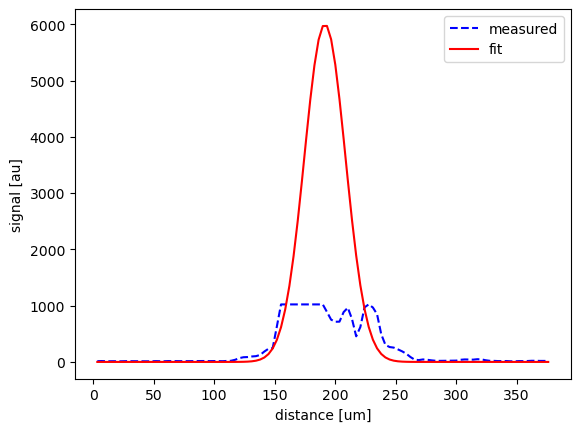

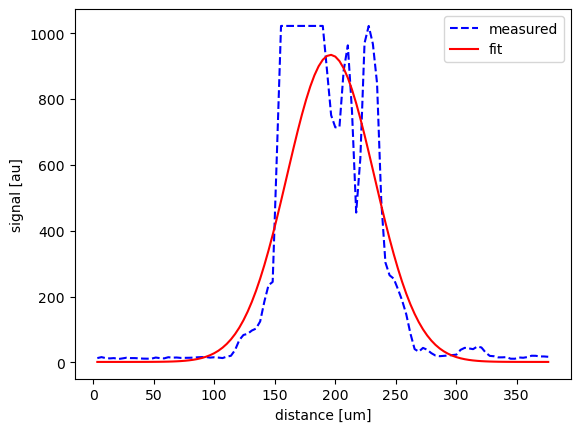

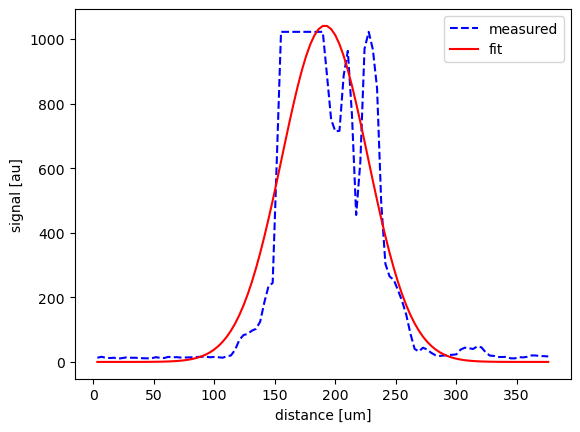

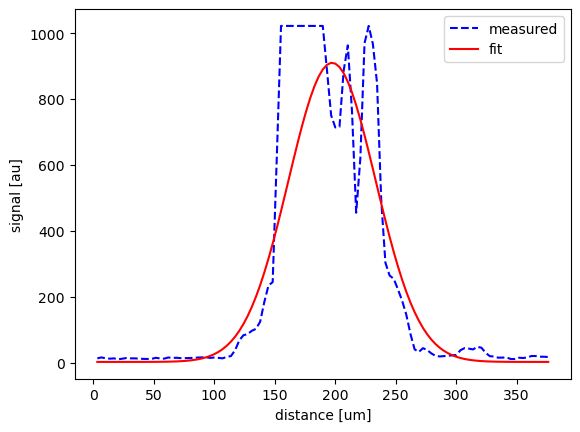

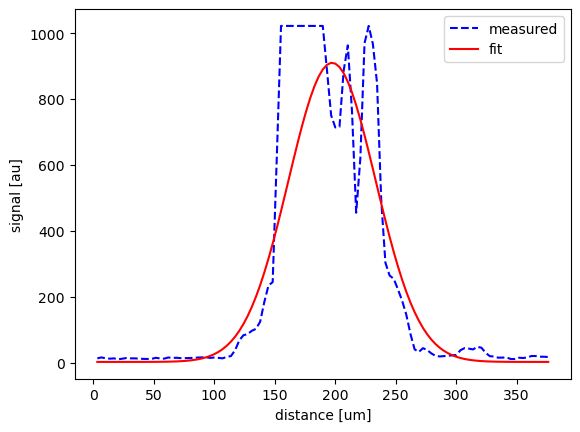

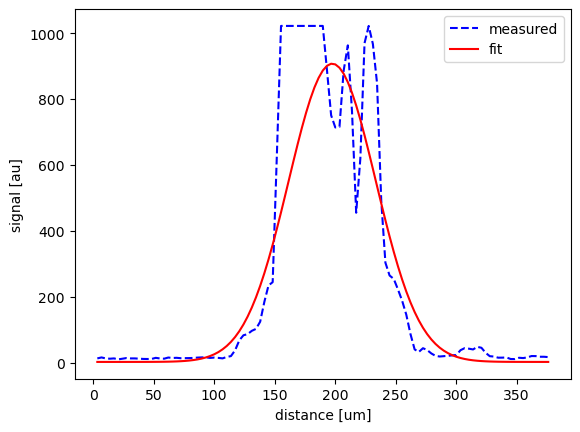

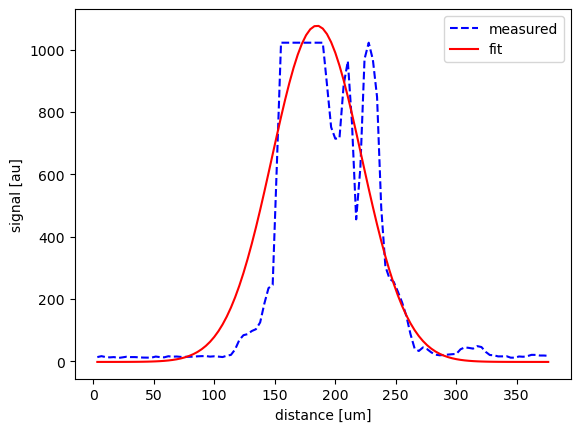

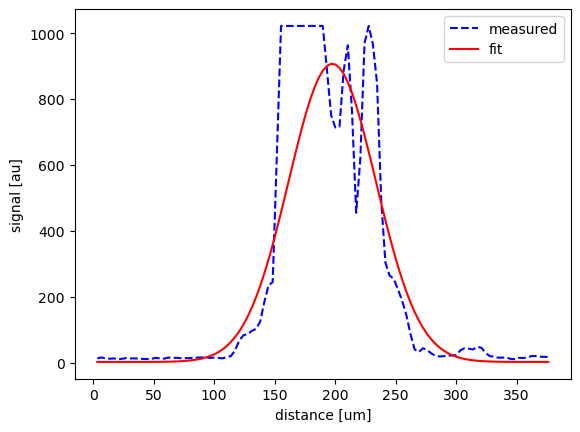

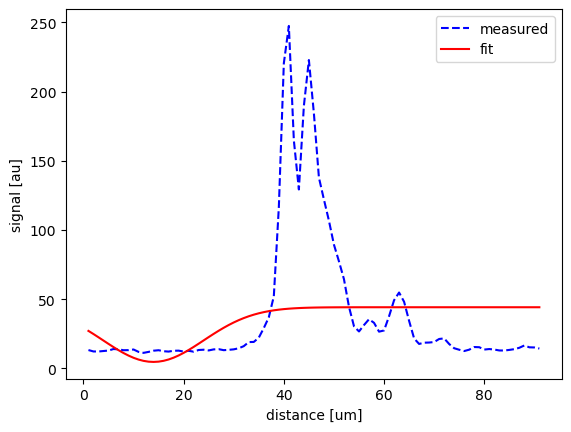

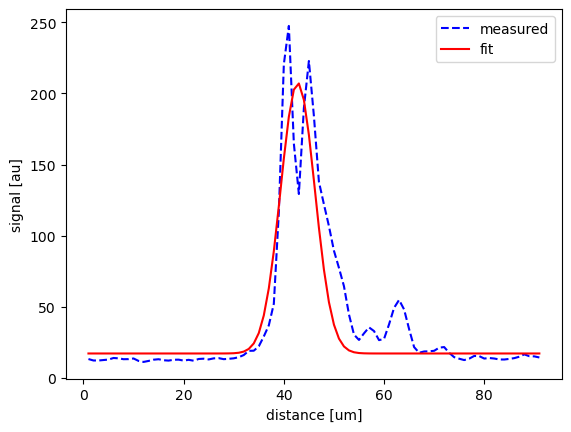

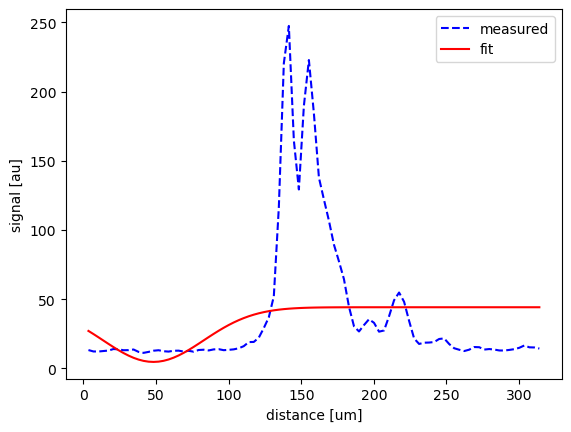

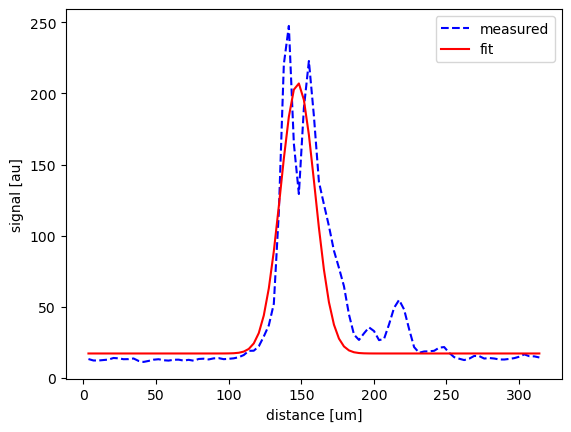

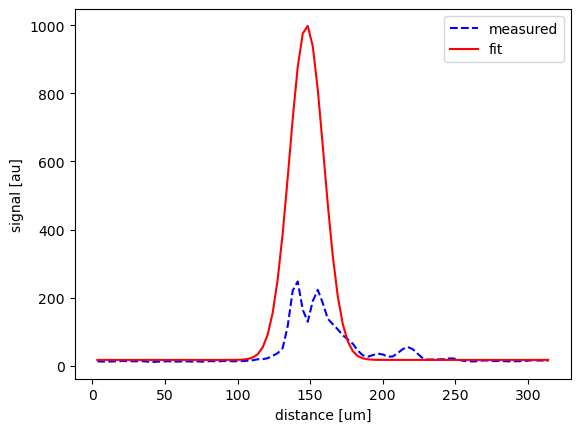

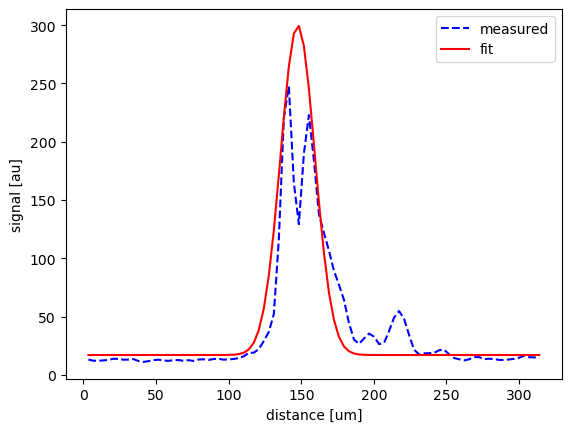

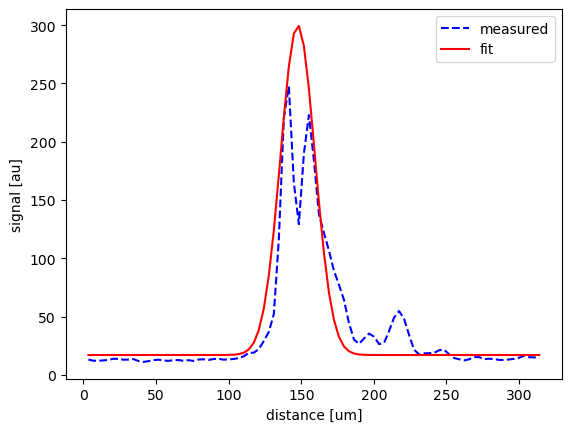

In [90]:
plt.figure()
plt.plot(dist, sig, 'b--', label = 'measured')
plt.plot(dist, func(dist, *popt1), 'r', label = 'fit')
plt.xlabel('distance [um]')
plt.ylabel('signal [au]')
plt.legend(loc = "best")
plt.show()

In [89]:
%matplotlib inline